In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "ball_detection").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if not (PROJECT_ROOT / "ball_detection").exists():
    raise RuntimeError(f"Could not find project root from {Path.cwd().resolve()}")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

PROJECT_ROOT


PosixPath('/home/bugslayer/Downloads/volley video footage')

In [2]:
import torch

from ball_detection.data.npz_dataset import (
    build_dataloaders,
    collect_train_val_npz_paths,
    get_input_channels,
)
from ball_detection.training.train_classifier import (
    BallCandidateCNN,
    fit,
    run_dataset_sanity_checks,
)


/home/bugslayer/Downloads/volley video footage/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
INPUT_MODE = "rgb_brightness"
TRAIN_BALL_DIR = Path("/home/bugslayer/Downloads/volley video footage/data/processing_folder/ball_datasets/videoplayback.1773931843922.publer.com-00.00.00.000-00.10.03.976-00.06.08.875-00.10.04.033/train/_ball/npz/")
VAL_BALL_DIR = Path("/home/bugslayer/Downloads/volley video footage/data/processing_folder/ball_datasets/videoplayback.1773931843922.publer.com-00.00.00.000-00.10.03.976-00.06.08.875-00.10.04.033/val/_ball/npz/")

TRAIN_NO_BALL_DIR = Path("/home/bugslayer/Downloads/volley video footage/data/processing_folder/ball_datasets/videoplayback.1773931843922.publer.com-00.00.00.000-00.10.03.976-00.06.08.875-00.10.04.033/train/_ball not/npz/")
VAL_NO_BALL_DIR = Path("/home/bugslayer/Downloads/volley video footage/data/processing_folder/ball_datasets/videoplayback.1773931843922.publer.com-00.00.00.000-00.10.03.976-00.06.08.875-00.10.04.033/val/_ball not/npz/")

BATCH_SIZE = 64
NUM_WORKERS = 4
EPOCHS = 20
LR = 1e-3
WEIGHT_DECAY = 1e-4
THRESHOLD = 0.8
MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
MODEL_SAVE_PATH = MODELS_DIR / "ball_cnn_best.pt"


In [4]:
train_split, val_split = collect_train_val_npz_paths(
    train_ball_dir=TRAIN_BALL_DIR,
    val_ball_dir=VAL_BALL_DIR,
    train_no_ball_dir=TRAIN_NO_BALL_DIR,
    val_no_ball_dir=VAL_NO_BALL_DIR,
)

sanity_summary = run_dataset_sanity_checks(
    train_split=train_split,
    val_split=val_split,
    input_mode=INPUT_MODE,
)
sanity_summary


train: ball=2023 no_ball=166823 total=168846
val: ball=547 no_ball=52891 total=53438
Sanity checks passed:
  train_ball_count: 2023
  train_no_ball_count: 166823
  val_ball_count: 547
  val_no_ball_count: 52891
  input_mode: rgb_brightness
  in_channels: 4
  sample_shape: (4, 64, 64)


{'train_ball_count': 2023,
 'train_no_ball_count': 166823,
 'val_ball_count': 547,
 'val_no_ball_count': 52891,
 'input_mode': 'rgb_brightness',
 'in_channels': 4,
 'sample_shape': (4, 64, 64)}

In [5]:
train_loader, val_loader = build_dataloaders(
    train_paths=train_split.all_paths,
    val_paths=val_split.all_paths,
    input_mode=INPUT_MODE,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)

in_channels = get_input_channels(INPUT_MODE)

# Replace this with your own model if you already have one.
model = BallCandidateCNN(in_channels=in_channels)

sample_x, sample_y = next(iter(train_loader))
sample_batch_size = min(sample_x.shape[0], 4)
sample_logits = model(sample_x[:sample_batch_size])
sample_loss = torch.nn.BCEWithLogitsLoss()(
    sample_logits.reshape(-1),
    sample_y[:sample_batch_size].reshape(-1),
)

print(f"sample_x shape: {tuple(sample_x.shape)}")
print(f"sample_y shape: {tuple(sample_y.shape)}")
print(f"sample_logits shape: {tuple(sample_logits.shape)}")
print(f"sample_loss: {sample_loss.item():.4f}")


sample_x shape: (64, 4, 64, 64)
sample_y shape: (64,)
sample_logits shape: (4, 1)
sample_loss: 0.5848


In [6]:
history = fit(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
    threshold=THRESHOLD,
    model_save_path=MODEL_SAVE_PATH,
)

history[-1]


Using device: cuda
Epoch 001/020 train_loss=0.0344 val_loss=0.0200 val_acc=0.9931 val_precision=0.9786 val_recall=0.3346 val_f1=0.4986 TP=183 TN=52887 FP=4 FN=364
Saved best model to /home/bugslayer/Downloads/volley video footage/models/ball_cnn_best.pt
Epoch 002/020 train_loss=0.0190 val_loss=0.0139 val_acc=0.9963 val_precision=0.8764 val_recall=0.7386 val_f1=0.8016 TP=404 TN=52834 FP=57 FN=143
Saved best model to /home/bugslayer/Downloads/volley video footage/models/ball_cnn_best.pt
Epoch 003/020 train_loss=0.0166 val_loss=0.0127 val_acc=0.9955 val_precision=0.9320 val_recall=0.6015 val_f1=0.7311 TP=329 TN=52867 FP=24 FN=218
Epoch 004/020 train_loss=0.0149 val_loss=0.0110 val_acc=0.9962 val_precision=0.9676 val_recall=0.6545 val_f1=0.7808 TP=358 TN=52879 FP=12 FN=189
Epoch 005/020 train_loss=0.0139 val_loss=0.0110 val_acc=0.9963 val_precision=0.9602 val_recall=0.6618 val_f1=0.7835 TP=362 TN=52876 FP=15 FN=185
Epoch 006/020 train_loss=0.0129 val_loss=0.0109 val_acc=0.9970 val_precisio

{'epoch': 20,
 'train_loss': 0.00621882003763474,
 'val_loss': 0.009233205881730985,
 'val_accuracy': 0.9974175680227554,
 'val_precision': 0.898635477582846,
 'val_recall': 0.8427787934186471,
 'val_f1': 0.8698113207547171,
 'tp': 461,
 'tn': 52839,
 'fp': 52,
 'fn': 86}

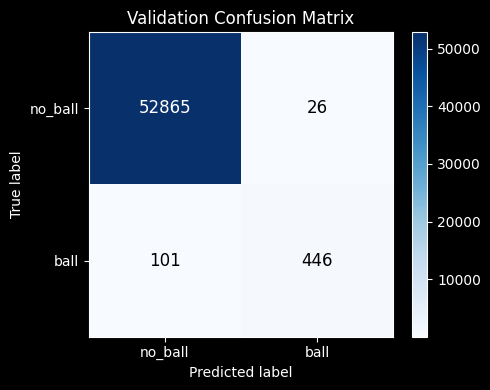

{'accuracy': 0.997623414049927,
 'precision': 0.9449152542372882,
 'recall': 0.8153564899451554,
 'f1': 0.8753680078508341,
 'tp': 446,
 'tn': 52865,
 'fp': 26,
 'fn': 101,
 'threshold': 0.8,
 'loss': 0.007479011738920327}

In [7]:
import matplotlib.pyplot as plt

from ball_detection.training.train_classifier import validate_one_epoch

checkpoint = torch.load(MODEL_SAVE_PATH, map_location="cpu")
model.load_state_dict(checkpoint["model_state_dict"])

val_metrics = validate_one_epoch(
    model=model,
    dataloader=val_loader,
    criterion=torch.nn.BCEWithLogitsLoss(),
    threshold=THRESHOLD,
)

confusion_matrix = [
    [int(val_metrics["tn"]), int(val_metrics["fp"])],
    [int(val_metrics["fn"]), int(val_metrics["tp"])],
]
class_names = ["no_ball", "ball"]

fig, ax = plt.subplots(figsize=(5, 4))
image = ax.imshow(confusion_matrix, cmap="Blues")
fig.colorbar(image, ax=ax)

ax.set_xticks(range(len(class_names)))
ax.set_yticks(range(len(class_names)))
ax.set_xticklabels(class_names)
ax.set_yticklabels(class_names)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Validation Confusion Matrix")

max_count = max(max(row) for row in confusion_matrix)
for row_index, row in enumerate(confusion_matrix):
    for col_index, value in enumerate(row):
        text_color = "white" if value > max_count / 2 else "black"
        ax.text(
            col_index,
            row_index,
            str(value),
            ha="center",
            va="center",
            color=text_color,
            fontsize=12,
        )

plt.tight_layout()
plt.show()

val_metrics
